In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = "mps"  # or "cpu"
print("Using:", device)


Using: mps


In [19]:
def simulate_measurement_bias_world(n_samples=10000):

    # FAIR true physiology
    race = np.random.choice([0,1,2], size=n_samples, p=[0.6,0.25,0.15])
    gender = np.random.choice([0,1], size=n_samples)
    age = np.random.normal(50, 10, n_samples).clip(18, 90)

    diabetes = np.random.binomial(1, 0.20, n_samples)

    glucose_non = np.random.normal(95, 8, n_samples)
    glucose_diab = np.random.normal(160, 20, n_samples)

    hba1c_non = np.random.normal(5.3, 0.25, n_samples)
    hba1c_diab = np.random.normal(7.0, 0.6, n_samples)

    glucose_true = np.where(diabetes==1, glucose_diab, glucose_non)
    hba1c_true   = np.where(diabetes==1, hba1c_diab, hba1c_non)

    # START BIAS
    glucose_meas = glucose_true.copy()
    hba1c_meas   = hba1c_true.copy()

    # Race 2: glucose underestimation
    glucose_meas[race == 2] -= 15

    # Females: HbA1c overestimation
    hba1c_meas[gender == 0] += 0.3

    # Race 1: extra measurement noise
    glucose_meas[race == 1] += np.random.normal(0, 10, (race==1).sum())
    hba1c_meas[race == 1]   += np.random.normal(0, 0.4, (race==1).sum())

    # Base measurement noise
    glucose_meas += np.random.normal(0, 5, n_samples)
    hba1c_meas   += np.random.normal(0, 0.15, n_samples)

    return pd.DataFrame({
        "race": race,
        "gender": gender,
        "age": age,
        "glucose_measured": glucose_meas,
        "hba1c_measured": hba1c_meas,
        "diabetes_label": diabetes
    })


In [20]:
df = simulate_measurement_bias_world(10000)

mlp_features = ["glucose_measured", "hba1c_measured", "age"]

X = df[mlp_features]
y = df["diabetes_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train prevalence:", y_train.mean())
print("Test prevalence:", y_test.mean())


Train prevalence: 0.198125
Test prevalence: 0.19


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.long).to(device)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.values, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=True)

test_loader = DataLoader(TensorDataset(X_test_t, y_test_t),
                         batch_size=32)


In [12]:
def train_epoch(model, train_dataloader, optimizer, loss_fn):
    losses = []
    correct_predictions = 0

    for features, labels in train_dataloader:
        output = model(features)
        optimizer.zero_grad()
        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        predicted = output.argmax(dim=1)
        correct_predictions += (predicted == labels).sum().item()

    acc = 100 * correct_predictions / len(train_dataloader.dataset)
    return np.mean(losses), acc


def evaluate(model, dataloader, loss_fn):
    losses = []
    correct_predictions = 0

    with torch.no_grad():
        for features, labels in dataloader:
            output = model(features)
            loss = loss_fn(output, labels)

            predicted = output.argmax(dim=1)
            correct_predictions += (predicted == labels).sum().item()
            losses.append(loss.item())

    acc = 100 * correct_predictions / len(dataloader.dataset)
    return np.mean(losses), acc


def train(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(n_epochs):
        model.train()
        tr_loss, tr_acc = train_epoch(model, train_dataloader, optimizer, loss_fn)
        model.eval()
        val_loss, val_acc = evaluate(model, val_dataloader, loss_fn)

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{n_epochs}: "
              f"train_loss={tr_loss:.4f}, train_acc={tr_acc:.2f}, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}")

    return train_losses, val_losses, train_accs, val_accs


In [28]:
def plot(train_losses, val_losses, train_accs, val_accs, title):
    plt.figure()
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["train_loss", "val_loss"])
    plt.title(title + " Loss")

    plt.figure()
    plt.plot(train_accs)
    plt.plot(val_accs)
    plt.legend(["train_acc", "val_acc"])
    plt.title(title + " Accuracy")


In [29]:
class MLP(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=32):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.model(x)


Epoch 1/20: train_loss=0.1340, train_acc=98.75, val_loss=0.0169, val_acc=99.55
Epoch 2/20: train_loss=0.0169, train_acc=99.44, val_loss=0.0128, val_acc=99.65
Epoch 3/20: train_loss=0.0155, train_acc=99.42, val_loss=0.0139, val_acc=99.65
Epoch 4/20: train_loss=0.0149, train_acc=99.45, val_loss=0.0139, val_acc=99.60
Epoch 5/20: train_loss=0.0146, train_acc=99.46, val_loss=0.0136, val_acc=99.65
Epoch 6/20: train_loss=0.0144, train_acc=99.50, val_loss=0.0128, val_acc=99.60
Epoch 7/20: train_loss=0.0142, train_acc=99.51, val_loss=0.0133, val_acc=99.65
Epoch 8/20: train_loss=0.0140, train_acc=99.51, val_loss=0.0137, val_acc=99.60
Epoch 9/20: train_loss=0.0138, train_acc=99.53, val_loss=0.0144, val_acc=99.65
Epoch 10/20: train_loss=0.0138, train_acc=99.47, val_loss=0.0145, val_acc=99.65
Epoch 11/20: train_loss=0.0138, train_acc=99.51, val_loss=0.0143, val_acc=99.65
Epoch 12/20: train_loss=0.0134, train_acc=99.55, val_loss=0.0132, val_acc=99.65
Epoch 13/20: train_loss=0.0138, train_acc=99.49, 

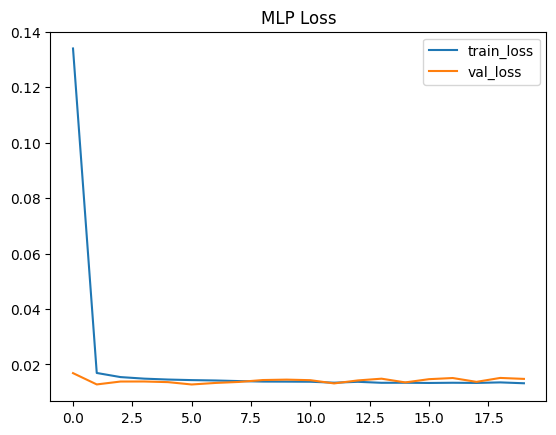

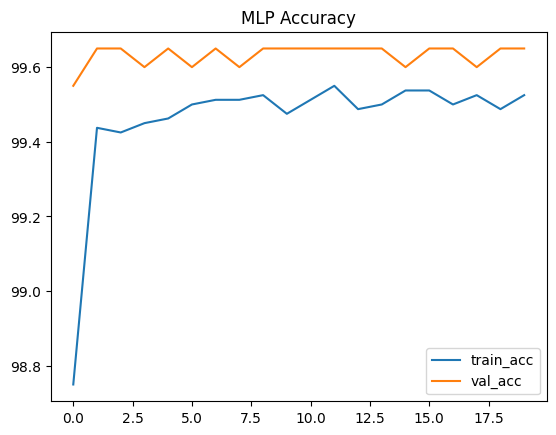

In [30]:
model = MLP().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model, train_loader, test_loader, optimizer, 20, loss_fn
)

plot(train_losses, val_losses, train_accs, val_accs, "MLP")


In [31]:
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    mlp_pred = logits.argmax(dim=1).cpu().numpy()
    mlp_probs = logits.softmax(dim=1)[:,1].cpu().numpy()

print("MLP Accuracy:", accuracy_score(y_test, mlp_pred))
print("MLP AUC:", roc_auc_score(y_test, mlp_probs))


MLP Accuracy: 0.678
MLP AUC: 0.504098440545809


In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:,1]

print("LR Accuracy:", accuracy_score(y_test, lr_pred))
print("LR AUC:", roc_auc_score(y_test, lr_probs))


LR Accuracy: 0.9925
LR AUC: 0.9998310591293047


In [23]:
def fairness_by_group(y_true, y_pred, group_values):
    results = {}
    for g in sorted(group_values.unique()):

        mask = (group_values == g)
        tn, fp, fn, tp = confusion_matrix(
            y_true[mask], y_pred[mask], labels=[0,1]
        ).ravel()

        results[g] = {
            "FPR": fp / (fp + tn) if (fp+tn)>0 else 0,
            "FNR": fn / (fn + tp) if (fn+tp)>0 else 0,
            "TPR": tp / (tp + fn) if (tp+fn)>0 else 0,
            "TNR": tn / (tn + fp) if (tn+fp)>0 else 0,
        }
    return pd.DataFrame(results).T


In [26]:
print("\n=== LR Fairness: RACE ===")
print(fairness_by_group(
    y_test.values,
    lr_pred,
    df.loc[X_test.index, "race"]
))

print("\n=== LR Fairness: GENDER ===")
print(fairness_by_group(
    y_test.values,
    lr_pred,
    df.loc[X_test.index, "gender"]
))



=== LR Fairness: RACE ===
        FPR       FNR       TPR       TNR
0  0.001028  0.008547  0.991453  0.998972
1  0.022005  0.010000  0.990000  0.977995
2  0.000000  0.043478  0.956522  1.000000

=== LR Fairness: GENDER ===
        FPR       FNR       TPR       TNR
0  0.008805  0.000000  1.000000  0.991195
1  0.003636  0.027933  0.972067  0.996364


In [27]:
print("\n=== MLP Fairness: RACE ===")
print(fairness_by_group(
    y_test.values,
    mlp_pred,
    df.loc[X_test.index, "race"]
))

print("\n=== MLP Fairness: GENDER ===")
print(fairness_by_group(
    y_test.values,
    mlp_pred,
    df.loc[X_test.index, "gender"]
))



=== MLP Fairness: RACE ===
        FPR       FNR       TPR       TNR
0  0.221994  0.820513  0.179487  0.778006
1  0.183374  0.830000  0.170000  0.816626
2  0.189076  0.717391  0.282609  0.810924

=== MLP Fairness: GENDER ===
        FPR       FNR       TPR       TNR
0  0.200000  0.805970  0.194030  0.800000
1  0.214545  0.815642  0.184358  0.785455
